# From Bayes' Theorem to Bayesian Inference

## Learning Objectives

By the end of this notebook you will be able to:

1. Restate **Bayes' theorem** and explain how it generalises from events to **parameter inference**.
2. Define **prior**, **likelihood**, **posterior**, and the **normalising constant** in the context of Bayesian inference.
3. Derive the **Beta-Binomial conjugate update** analytically and compute a posterior by hand.
4. Perform **sequential Bayesian updating** and visualise how the posterior sharpens with more data.
5. Implement a simple Bayesian model in **PyMC** and compare its posterior to the analytical result.
6. Articulate the key differences between **Bayesian** and **Frequentist** inference.

## Prerequisites

- [Module 01 — Conditional probability & Bayes' theorem](../01_probability_basics/03_conditional_probability.ipynb)
- [Module 02 — Beta and Binomial distributions](../02_distributions/01_discrete_distributions.ipynb)
- [Module 04 — Point estimation and MLE](../04_estimation/03_maximum_likelihood.ipynb)

In [1]:
import sys, os, shutil
from pathlib import Path

IN_COLAB = "google.colab" in sys.modules
if IN_COLAB:
    os.system(
        "sudo apt-get update -qq && sudo apt-get install -y -qq "
        "libcairo2-dev libpango1.0-dev && pip install -q manim pymc arviz ipython==8.21.0"
    )

_miktex_bin = Path.home() / "AppData/Local/Programs/MiKTeX/miktex/bin/x64"
if _miktex_bin.exists() and str(_miktex_bin) not in os.environ.get("PATH", ""):
    os.environ["PATH"] += os.pathsep + str(_miktex_bin)

import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

sys.path.insert(0, os.path.abspath("../../src"))
from amstats.plotting import apply_style

apply_style()


class Cfg:
    root = Path("../../").resolve()
    gif_dir = root / "media" / "gifs"
    has_latex: bool = (
        shutil.which("latex") is not None or shutil.which("pdflatex") is not None
    )

    def __init__(self):
        self.gif_dir.mkdir(parents=True, exist_ok=True)

    def apply_manim_config(self):
        from manim import config as mcfg

        mcfg.format = "gif"

    def math_text(self, expr, **kwargs):
        from manim import MathTex, Text

        if self.has_latex:
            return MathTex(expr, **kwargs)
        return Text(expr, **kwargs)

    def save_gifs(self, clean=True):
        local_media = Path("media")
        found = list(local_media.rglob("*.gif")) if local_media.exists() else []
        if not found:
            print("  No new GIFs to save.")
            return
        for gif in found:
            dest = self.gif_dir / gif.name
            shutil.copy2(gif, dest)
            print(f"  ✓ media/gifs/{gif.name}")
        if clean:
            for sub in ("videos", "images", "Tex"):
                d = local_media / sub
                if d.exists():
                    shutil.rmtree(d, ignore_errors=True)
            print("  Cleaned up local temp render files (kept media/jupyter/).")


cfg = Cfg()
rng = np.random.default_rng(42)

---

## 1. Recap: Bayes' Theorem for Events

In Module 01 we proved **Bayes' theorem** for events:

$$P(A \mid B) = \frac{P(B \mid A)\,P(A)}{P(B)}$$

This tells us how to *reverse* a conditional probability.  We know $P(B \mid A)$ (the probability of observing $B$ given that $A$ is true) and we want $P(A \mid B)$ (the probability that $A$ is true given that we observed $B$).

**Quick example.** A medical test has 95% sensitivity ($P(\text{positive} \mid \text{disease}) = 0.95$) and 90% specificity ($P(\text{negative} \mid \text{healthy}) = 0.90$).  If the disease prevalence is 1%, what is the probability that a person who tests positive actually has the disease?

$$P(\text{disease} \mid +) = \frac{0.95 \times 0.01}{0.95 \times 0.01 + 0.10 \times 0.99} = \frac{0.0095}{0.1085} \approx 0.088$$

Only about 8.8%. This is Bayes' theorem doing what it does best: combining prior knowledge (prevalence) with new evidence (the test result) to update our belief.

So far, so familiar.  The conceptual leap in this module is to apply the *same logic* not to discrete events, but to **continuous parameters**.

---

## 2. Bayes as an Inference Engine

Suppose we have a statistical model with an unknown parameter $\theta$ (e.g., the bias of a coin, the mean of a Normal distribution, a regression coefficient).  We observe data $\mathbf{x} = (x_1, \dots, x_n)$.  We want to learn about $\theta$.

### The Bayesian framework

Replace the letters in Bayes' theorem:

$$\boxed{P(\theta \mid \mathbf{x}) = \frac{P(\mathbf{x} \mid \theta)\,P(\theta)}{P(\mathbf{x})}}$$

Each term has a name and a specific role:

| Symbol                      | Name                               | Meaning                                                                                                                                                                                    |
|-----------------------------|------------------------------------|--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------|
| $P(\theta)$                 | **Prior**                          | Our belief about $\theta$ *before* seeing the data. This encodes existing knowledge, expert opinion, or deliberate vagueness.                                                              |
| $P(\mathbf{x} \mid \theta)$ | **Likelihood**                     | How probable is the observed data if $\theta$ were the true parameter value? This is the *same* likelihood function from MLE (Module 04) — but now it's one ingredient in a larger recipe. |
| $P(\theta \mid \mathbf{x})$ | **Posterior**                      | Our updated belief about $\theta$ *after* seeing the data. This is what we want.                                                                                                           |
| $P(\mathbf{x})$             | **Marginal likelihood** (evidence) | A normalising constant that ensures the posterior integrates to 1.                                                                                                                         |

### The proportionality shortcut

Since $P(\mathbf{x})$ doesn't depend on $\theta$, we often write:

$$\boxed{P(\theta \mid \mathbf{x}) \propto P(\mathbf{x} \mid \theta) \cdot P(\theta)}$$

In words: **posterior is proportional to likelihood times prior**.  This is the central equation of Bayesian statistics.

### Intuition

Think of the prior as your *starting belief* — maybe you think a coin is roughly fair, but you're not sure.  The likelihood tells you *how well each possible value of $\theta$ explains the data you saw*.  The posterior combines both: values of $\theta$ that were plausible a priori *and* explain the data well get the most posterior weight.

- **Strong prior, weak data:** The posterior looks like the prior.  Your initial belief dominates.
- **Weak prior, strong data:** The posterior looks like the likelihood.  The data overwhelms your prior.
- **Both informative:** The posterior is a compromise.

This is *exactly* how rational belief updating should work.

---

## 3. The Normalising Constant — Why It's Hard

The denominator $P(\mathbf{x})$ is the **marginal likelihood** (also called the **evidence**):

$$P(\mathbf{x}) = \int P(\mathbf{x} \mid \theta)\,P(\theta)\,d\theta$$

This integral is over the *entire parameter space*.  It marginalises out $\theta$ to give the overall probability of the data under all possible parameter values, weighted by the prior.

**Why does this matter?** To get an actual probability distribution (not just something proportional to one), you need $P(\mathbf{x})$.  But this integral is often **analytically intractable**:

- For a 1-parameter model, it's a 1D integral — usually manageable.
- For a regression with 100 predictors, it's a 100-dimensional integral.
- For a hierarchical model, the dimensionality can be in the thousands.

High-dimensional integrals cannot be computed by quadrature.  This is the fundamental computational challenge of Bayesian statistics, and it's what motivates **Markov Chain Monte Carlo (MCMC)** — the subject of a later notebook.

**For now:** In the examples below, we'll use a special case (conjugate priors) where $P(\mathbf{x})$ has a closed form.  This lets us focus on the *concepts* without worrying about computation.

---

## 4. Concrete Example: Coin Bias Estimation

This is the "hello world" of Bayesian inference.  We flip a coin $n$ times and observe $k$ heads.  We want to infer the coin's bias $\theta \in [0, 1]$, where $\theta = P(\text{heads})$.

### Step 1: Choose a likelihood

Given $\theta$, the number of heads in $n$ flips follows a Binomial distribution:

$$P(k \mid \theta) = \binom{n}{k} \theta^k (1-\theta)^{n-k}$$

### Step 2: Choose a prior

We need a prior distribution over $\theta \in [0, 1]$.  The **Beta distribution** is the natural choice:

$$P(\theta) = \text{Beta}(\theta; \alpha, \beta) = \frac{\theta^{\alpha-1}(1-\theta)^{\beta-1}}{B(\alpha, \beta)}$$

where $B(\alpha, \beta) = \frac{\Gamma(\alpha)\Gamma(\beta)}{\Gamma(\alpha+\beta)}$ is the Beta function.

**Interpretation of the hyperparameters:** Think of $\alpha - 1$ as "prior pseudo-heads" and $\beta - 1$ as "prior pseudo-tails".  Before seeing any data, the Beta prior behaves as if you've already seen $\alpha + \beta - 2$ flips.

Common choices:
- $\text{Beta}(1, 1)$: Uniform — total ignorance.
- $\text{Beta}(2, 2)$: Mild preference for values near 0.5.
- $\text{Beta}(10, 10)$: Fairly confident the coin is close to fair.

### Step 3: Compute the posterior

$$P(\theta \mid k) \propto P(k \mid \theta) \cdot P(\theta) = \binom{n}{k} \theta^k (1-\theta)^{n-k} \cdot \frac{\theta^{\alpha-1}(1-\theta)^{\beta-1}}{B(\alpha, \beta)}$$

Drop constants that don't depend on $\theta$:

$$P(\theta \mid k) \propto \theta^{k + \alpha - 1}(1-\theta)^{(n-k) + \beta - 1}$$

This is the kernel of a **Beta distribution** with updated parameters:

$$\boxed{\theta \mid k \sim \text{Beta}(\alpha + k, \; \beta + n - k)}$$

That's it.  The prior was $\text{Beta}(\alpha, \beta)$, and after observing $k$ heads in $n$ flips, the posterior is $\text{Beta}(\alpha + k, \beta + n - k)$.  The update rule is just: **add the observed heads to $\alpha$, add the observed tails to $\beta$**.

This elegant property — where the posterior belongs to the same family as the prior — is called **conjugacy**.  The Beta distribution is the conjugate prior for the Binomial likelihood.  We'll explore conjugacy systematically in the next notebook.

### Numerical example

Suppose we observe **$k = 7$ heads in $n = 10$ flips**, and we start with a uniform prior $\text{Beta}(1, 1)$:

- Prior: $\text{Beta}(1, 1)$ — uniform on $[0, 1]$
- Likelihood: $\text{Binomial}(10, \theta)$ with $k = 7$
- Posterior: $\text{Beta}(1 + 7, 1 + 3) = \text{Beta}(8, 4)$

Key summaries of the posterior:
- Posterior mean: $\frac{\alpha'}{\alpha' + \beta'} = \frac{8}{12} = 0.667$
- Posterior mode (MAP): $\frac{\alpha' - 1}{\alpha' + \beta' - 2} = \frac{7}{10} = 0.700$ — this equals the MLE!
- 95% credible interval: we can compute this exactly from the Beta CDF.

In [ ]:
# ── Coin bias estimation: Beta-Binomial conjugate update ──
n_flips, k_heads = 10, 7
alpha_prior, beta_prior = 1, 1  # Uniform prior

# Posterior parameters
alpha_post = alpha_prior + k_heads
beta_post = beta_prior + (n_flips - k_heads)

prior = stats.beta(alpha_prior, beta_prior)
posterior = stats.beta(alpha_post, beta_post)

# Posterior summaries
post_mean = alpha_post / (alpha_post + beta_post)
post_mode = (alpha_post - 1) / (alpha_post + beta_post - 2)
ci_95 = posterior.ppf([0.025, 0.975])

print(f"Data: {k_heads} heads in {n_flips} flips")
print(f"Prior:     Beta({alpha_prior}, {beta_prior})")
print(f"Posterior: Beta({alpha_post}, {beta_post})")
print(f"")
print(f"Posterior mean:  {post_mean:.3f}")
print(f"Posterior mode:  {post_mode:.3f}  (= MLE = k/n)")
print(f"95% credible interval: [{ci_95[0]:.3f}, {ci_95[1]:.3f}]")

Data: 7 heads in 10 flips
Prior:     Beta(1, 1)
Posterior: Beta(8, 4)

Posterior mean:  0.667
Posterior mode:  0.700  (= MLE = k/n)
95% credible interval: [0.390, 0.891]


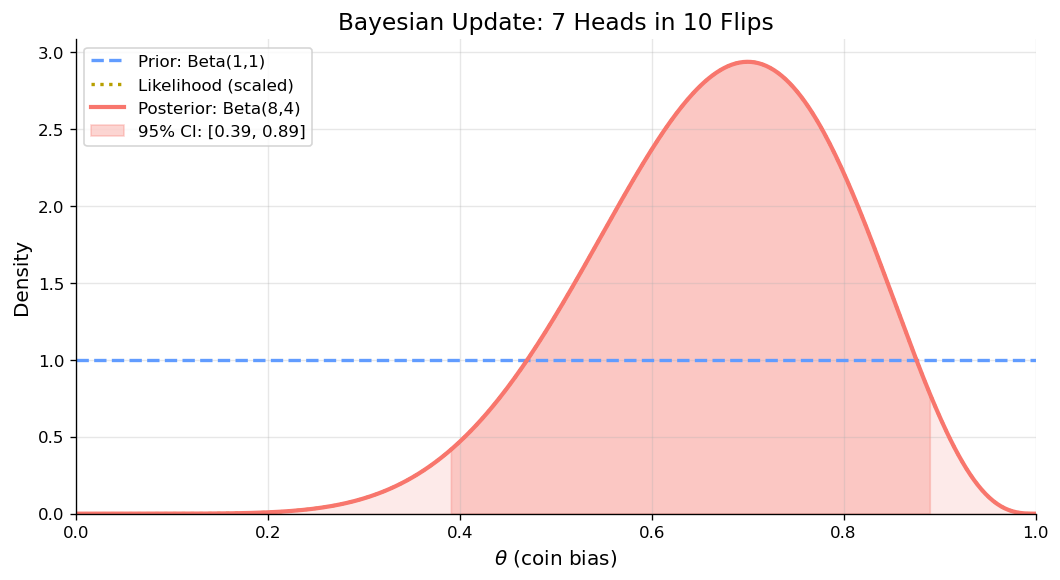

In [ ]:
# ── Visualise prior, likelihood (rescaled), and posterior ──
theta = np.linspace(0, 1, 500)

prior_pdf = prior.pdf(theta)
posterior_pdf = posterior.pdf(theta)

# Likelihood function (not a proper density — rescale for visual comparison)
likelihood = theta**k_heads * (1 - theta) ** (n_flips - k_heads)
likelihood_scaled = likelihood / likelihood.max() * posterior_pdf.max()

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(
    theta,
    prior_pdf,
    "--",
    linewidth=2,
    color="#619CFF",
    label=f"Prior: Beta({alpha_prior},{beta_prior})",
)
ax.plot(
    theta,
    likelihood_scaled,
    ":",
    linewidth=2,
    color="#B79F00",
    label=f"Likelihood (scaled)",
)
ax.plot(
    theta,
    posterior_pdf,
    "-",
    linewidth=2.5,
    color="#F8766D",
    label=f"Posterior: Beta({alpha_post},{beta_post})",
)
ax.fill_between(theta, posterior_pdf, alpha=0.15, color="#F8766D")

# Mark the 95% credible interval
ci_mask = (theta >= ci_95[0]) & (theta <= ci_95[1])
ax.fill_between(
    theta[ci_mask],
    posterior_pdf[ci_mask],
    alpha=0.3,
    color="#F8766D",
    label=f"95% CI: [{ci_95[0]:.2f}, {ci_95[1]:.2f}]",
)

ax.set_xlabel(r"$\theta$ (coin bias)")
ax.set_ylabel("Density")
ax.set_title(f"Bayesian Update: {k_heads} Heads in {n_flips} Flips")
ax.legend(fontsize=10)
ax.set_xlim(0, 1)
ax.set_ylim(bottom=0)
plt.tight_layout()
plt.show()

The flat blue prior reflects total ignorance.  After seeing 7 heads in 10 flips, the red posterior concentrates around $\theta \approx 0.7$.  The gold likelihood curve (rescaled for visual comparison) shows which values of $\theta$ best explain the data — the posterior is a compromise between prior and likelihood.

With a uniform prior, the posterior mode equals the MLE ($\hat{\theta} = 7/10 = 0.7$).  But the posterior gives us *much more* than a point estimate: we get an entire distribution over $\theta$, from which we can read off credible intervals, compute probabilities like $P(\theta > 0.5 \mid \text{data})$, and quantify our uncertainty.

In [4]:
# Posterior probabilities — things you can't easily do with MLE
prob_biased = 1 - posterior.cdf(0.5)
prob_very_biased = 1 - posterior.cdf(0.8)

print(f"P(θ > 0.5 | data) = {prob_biased:.3f}  — probability the coin favours heads")
print(f"P(θ > 0.8 | data) = {prob_very_biased:.3f}  — probability of strong bias")

P(θ > 0.5 | data) = 0.887  — probability the coin favours heads
P(θ > 0.8 | data) = 0.161  — probability of strong bias


---

## 5. Sequential Bayesian Updating

One of the most beautiful features of Bayesian inference is that it is **inherently sequential**.  You can update your beliefs one observation at a time, and the final result is the same as if you'd processed all the data at once.

This works because yesterday's posterior becomes today's prior:

$$P(\theta \mid x_1, \dots, x_{t+1}) \propto P(x_{t+1} \mid \theta) \cdot \underbrace{P(\theta \mid x_1, \dots, x_t)}_{\text{yesterday's posterior = today's prior}}$$

For our coin example: start with $\text{Beta}(1, 1)$, then after each flip, update $\alpha$ or $\beta$ by 1.

The following animation shows this process in action.

In [5]:
from manim import *

cfg.apply_manim_config()

Manim Community v0.18.1

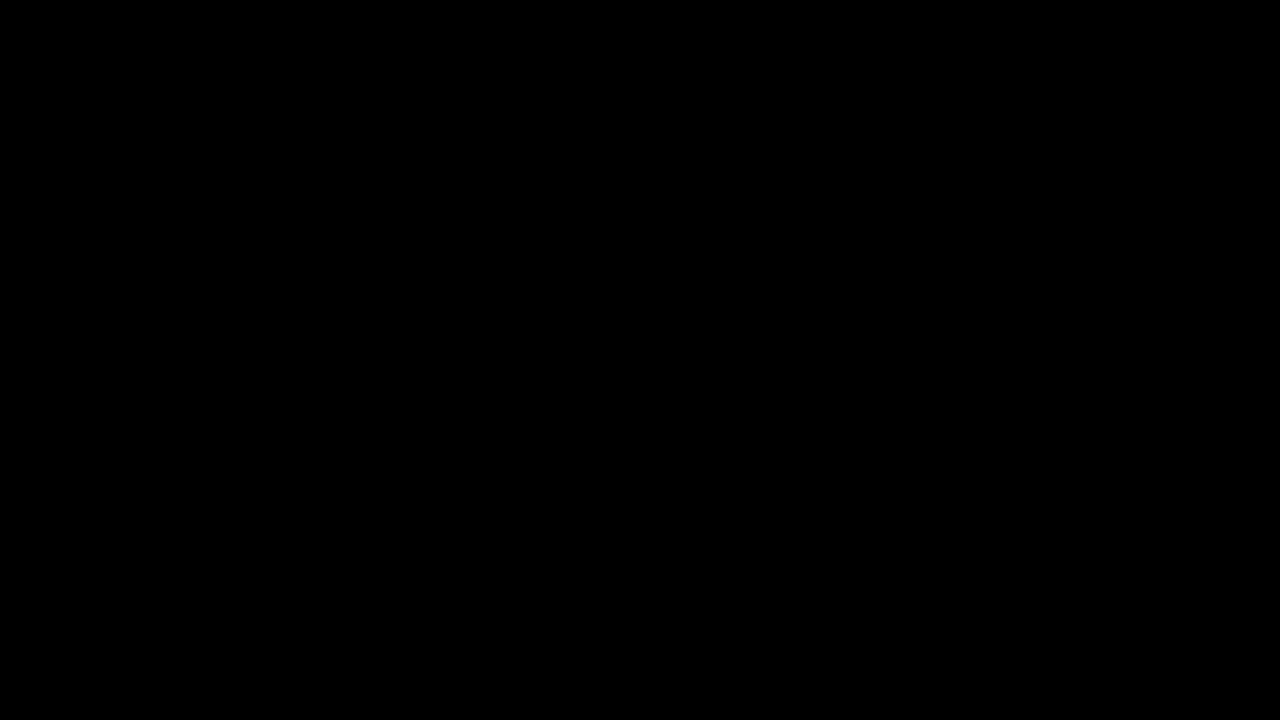

In [ ]:
%%manim -qm -v WARNING BayesianUpdating

from amstats.manim_utils import C


class BayesianUpdating(Scene):
    """Sequential Bayesian updating of coin bias.

    Shows the Beta prior evolving flip-by-flip as data arrives.
    The distribution sharpens and migrates toward the true bias.
    """

    def construct(self):
        # ── Configuration ──
        true_p = 0.7
        flips = [1, 0, 1, 1, 0, 1, 1, 1, 0, 1]  # 7 heads in 10 flips

        # ── Axes ──
        axes = Axes(
            x_range=[0, 1, 0.2],
            y_range=[0, 5, 1],
            x_length=9,
            y_length=5,
            axis_config={"include_numbers": True, "font_size": 22},
        ).shift(DOWN * 0.3)
        x_label = MathTex(r"\theta", font_size=28).next_to(axes.x_axis, RIGHT, buff=0.2)
        y_label = MathTex(r"p(\theta)", font_size=28).next_to(axes.y_axis, UP, buff=0.2)
        self.play(Create(axes), Write(x_label), Write(y_label), run_time=1)

        # True value marker
        true_line = axes.get_vertical_line(
            axes.c2p(true_p, 4.5),
            line_config={"dashed_ratio": 0.5},
            color=GREY,
        )
        true_label = MathTex(
            r"\theta_{\text{true}}=0.7", font_size=22, color=GREY
        ).next_to(true_line, UP, buff=0.1)
        self.play(Create(true_line), Write(true_label), run_time=0.6)

        # ── Helper: Beta PDF clamped to y-range ──
        from scipy.stats import beta as beta_dist

        def beta_curve(a, b, color):
            x_vals = np.linspace(0.005, 0.995, 300)
            y_vals = beta_dist.pdf(x_vals, a, b)
            y_vals = np.clip(y_vals, 0, 4.9)
            points = [axes.c2p(x, y) for x, y in zip(x_vals, y_vals)]
            return (
                VMobject()
                .set_points_smoothly(points)
                .set_color(color)
                .set_stroke(width=3)
            )

        # ── Title & counter ──
        title = Text(
            "Sequential Bayesian Updating", font_size=30, color=C.LABEL
        ).to_edge(UP, buff=0.3)
        self.play(Write(title), run_time=0.6)

        # Status display
        status = Text("Prior: Beta(1, 1)", font_size=22, color=C.PERIWINKLE).to_corner(
            UR, buff=0.4
        )
        flip_display = Text("Flips: ", font_size=22, color=C.LABEL).next_to(
            status, DOWN, aligned_edge=LEFT, buff=0.3
        )
        self.play(Write(status), Write(flip_display), run_time=0.5)

        # ── Initial prior ──
        alpha, beta_param = 1, 1
        current_curve = beta_curve(alpha, beta_param, C.PERIWINKLE)
        self.play(Create(current_curve), run_time=0.8)
        self.wait(0.8)

        # ── Sequential updates ──
        flip_symbols = []
        for i, flip in enumerate(flips):
            # Show the flip result
            symbol = "H" if flip == 1 else "T"
            sym_color = C.GOLD if flip == 1 else C.CYAN
            flip_text = Text(symbol, font_size=22, color=sym_color)
            flip_symbols.append(flip_text)

            # Arrange flip symbols in a row
            flip_row = VGroup(*flip_symbols).arrange(RIGHT, buff=0.12)
            flip_row.next_to(flip_display, RIGHT, buff=0.15)

            # Update parameters
            alpha += flip
            beta_param += 1 - flip

            # New curve
            new_curve = beta_curve(alpha, beta_param, C.SALMON)

            # New status text
            new_status = Text(
                f"Posterior: Beta({alpha}, {beta_param})",
                font_size=22,
                color=C.SALMON,
            ).to_corner(UR, buff=0.4)

            self.play(
                FadeIn(flip_symbols[-1]),
                Transform(current_curve, new_curve),
                Transform(status, new_status),
                run_time=0.7,
            )
            self.wait(0.3)

        # ── Final pause ──
        final_note = Text(
            f"Final: Beta({alpha}, {beta_param})  —  Mean = {alpha / (alpha + beta_param):.2f}",
            font_size=24,
            color=C.SALMON,
        ).next_to(axes, DOWN, buff=0.4)
        self.play(Write(final_note), run_time=0.8)
        self.wait(1.5)

Watch how the distribution starts flat (total ignorance) and progressively concentrates around the true value $\theta = 0.7$.  After just 10 flips, we already have a fairly informative posterior.  With 100 flips, the posterior would be very narrow — the data overwhelms the prior.

Notice also that the posterior shifts after *every single observation*.  A head nudges it right; a tail nudges it left.  This is Bayesian learning in its purest form.

---

## 6. The Effect of the Prior

How much does the prior matter?  Let's compare three priors — uninformative, mildly informative, and strongly informative — all updated with the same data ($k = 7$ heads in $n = 10$ flips).

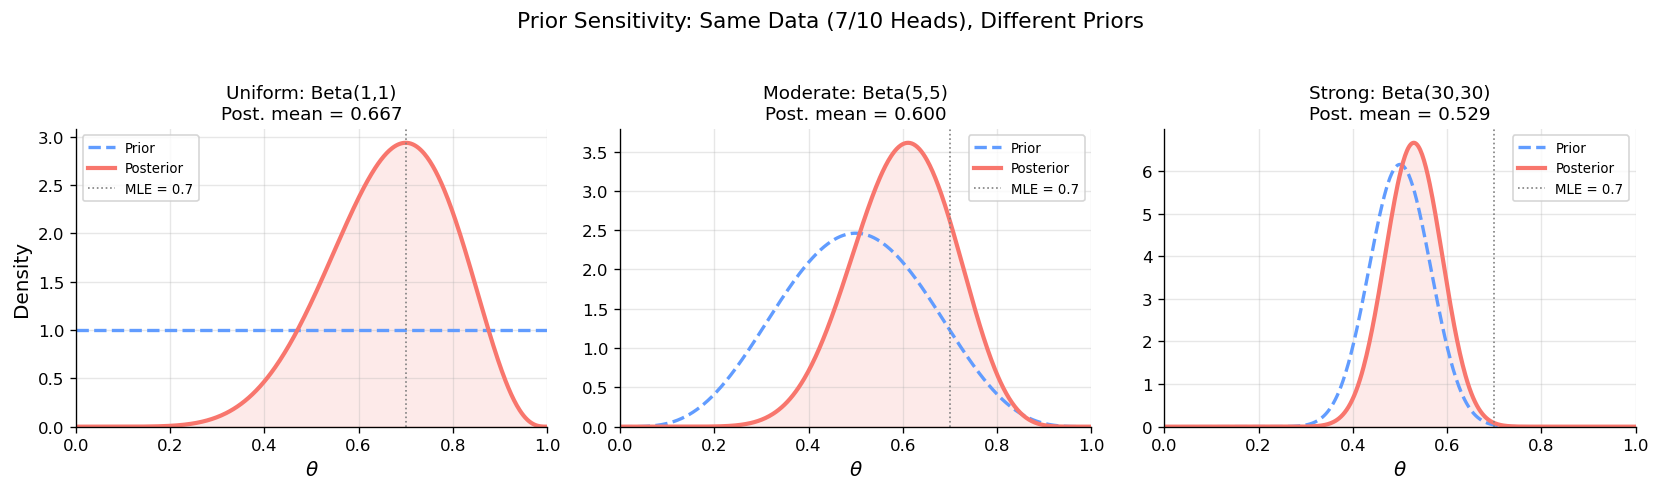

In [ ]:
# ── Effect of prior strength ──
priors = [
    (1, 1, "Uniform: Beta(1,1)"),
    (5, 5, "Moderate: Beta(5,5)"),
    (30, 30, "Strong: Beta(30,30)"),
]

theta = np.linspace(0, 1, 500)
fig, axes_list = plt.subplots(1, 3, figsize=(14, 4), sharey=False)

colors_prior = ["#619CFF", "#619CFF", "#619CFF"]
colors_post = ["#F8766D", "#F8766D", "#F8766D"]

for ax, (a, b, label) in zip(axes_list, priors):
    prior_d = stats.beta(a, b)
    post_d = stats.beta(a + k_heads, b + n_flips - k_heads)

    ax.plot(theta, prior_d.pdf(theta), "--", lw=2, color="#619CFF", label="Prior")
    ax.plot(theta, post_d.pdf(theta), "-", lw=2.5, color="#F8766D", label="Posterior")
    ax.fill_between(theta, post_d.pdf(theta), alpha=0.15, color="#F8766D")
    ax.axvline(0.7, color="grey", ls=":", lw=1, label="MLE = 0.7")

    post_mean = (a + k_heads) / (a + b + n_flips)
    ax.set_title(f"{label}\nPost. mean = {post_mean:.3f}", fontsize=11)
    ax.set_xlabel(r"$\theta$")
    ax.set_xlim(0, 1)
    ax.set_ylim(bottom=0)
    ax.legend(fontsize=8)

axes_list[0].set_ylabel("Density")
fig.suptitle(
    f"Prior Sensitivity: Same Data ({k_heads}/{n_flips} Heads), Different Priors",
    fontsize=13,
    y=1.02,
)
plt.tight_layout()
plt.show()

**Observations:**

- **Uniform prior** ($\alpha = \beta = 1$): The posterior is entirely driven by the data.  Mean $\approx$ MLE.
- **Moderate prior** ($\alpha = \beta = 5$): The prior "pulls" the posterior slightly toward 0.5.  The posterior mean is between the prior mean and the MLE.
- **Strong prior** ($\alpha = \beta = 30$): The prior strongly believes the coin is fair.  With only 10 flips of data, the posterior barely moves from 0.5.  We'd need much more data to overcome this prior.

This is both a feature and a responsibility.  Informative priors can be powerful when they encode genuine knowledge (e.g., physical constraints, previous experiments).  But a poorly chosen prior can dominate the data.  As $n \to \infty$, any "reasonable" prior is eventually overwhelmed — the posterior concentrates on the true value regardless.  This is the **Bernstein-von Mises theorem**, the Bayesian analogue of consistency.

---

## 7. Professional Tool: PyMC

For the coin flip example, we derived the posterior analytically.  In practice, most models don't have conjugate closed forms.  **PyMC** is a probabilistic programming library that automates Bayesian inference using MCMC sampling.

Let's verify our analytical result with PyMC — the posteriors should match.

In [ ]:
# PyTensor Windows fix: skip C compilation
os.environ["PYTENSOR_FLAGS"] = "device=cpu,floatX=float64,cxx="
import pymc as pm
import arviz as az

# ── PyMC model: coin bias estimation ──
with pm.Model() as coin_model:
    # Prior
    theta = pm.Beta("theta", alpha=1, beta=1)

    # Likelihood
    y = pm.Binomial("y", n=n_flips, p=theta, observed=k_heads)

    # Sample from the posterior
    trace = pm.sample(2000, tune=1000, random_seed=42, progressbar=True)

print(az.summary(trace, var_names=["theta"], round_to=3))

In [ ]:
# ── Compare PyMC posterior to analytical Beta(8, 4) ──
theta_grid = np.linspace(0, 1, 500)
analytical_pdf = stats.beta.pdf(theta_grid, alpha_post, beta_post)

fig, ax = plt.subplots(figsize=(9, 5))

# PyMC samples histogram
theta_samples = az.extract(trace, var_names=["theta"])["theta"].values
ax.hist(
    theta_samples,
    bins=50,
    density=True,
    alpha=0.4,
    color="#619CFF",
    label="PyMC posterior (MCMC samples)",
)

# Analytical posterior
ax.plot(
    theta_grid,
    analytical_pdf,
    "-",
    lw=2.5,
    color="#F8766D",
    label=f"Analytical: Beta({alpha_post}, {beta_post})",
)

ax.set_xlabel(r"$\theta$")
ax.set_ylabel("Density")
ax.set_title("PyMC vs. Analytical Posterior")
ax.legend(fontsize=10)
ax.set_xlim(0, 1)
plt.tight_layout()
plt.show()

print(f"\nAnalytical posterior mean: {post_mean:.3f}")
print(f"PyMC posterior mean:      {theta_samples.mean():.3f}")

The MCMC samples (blue histogram) match the analytical posterior (red curve) closely.  For this simple model, PyMC is overkill — but the same code structure scales to models where no analytical solution exists: hierarchical models, regression, mixture models, and more.  That's the power of probabilistic programming.

---

## 8. Bayesian vs. Frequentist: A Comparison

The table below summarises the fundamental philosophical and practical differences between the two paradigms:

| Aspect                            | Bayesian                                                                                                        | Frequentist                                                                                                |
|-----------------------------------|-----------------------------------------------------------------------------------------------------------------|------------------------------------------------------------------------------------------------------------|
| **What is probability?**          | Degree of belief (subjective/epistemic)                                                                         | Long-run frequency of events                                                                               |
| **What is a parameter $\theta$?** | A random variable with a probability distribution                                                               | A fixed but unknown constant                                                                               |
| **What do we condition on?**      | The observed data (fixed); $\theta$ varies                                                                      | The parameter (fixed); data varies across hypothetical repetitions                                         |
| **Primary output**                | Posterior distribution $P(\theta \mid \text{data})$                                                             | Point estimate $\hat{\theta}$ and confidence interval                                                      |
| **Interval interpretation**       | $P(\theta \in [a, b] \mid \text{data}) = 0.95$ — there is a 95% probability that $\theta$ lies in this interval | If we repeated the experiment many times, 95% of the constructed intervals would contain the true $\theta$ |
| **Prior information**             | Formally incorporated via $P(\theta)$                                                                           | Not used (or informally via study design)                                                                  |
| **Small samples**                 | Works naturally — prior stabilises inference                                                                    | Can be unreliable; asymptotics may not apply                                                               |
| **Computational cost**            | Often requires MCMC or variational inference                                                                    | Usually closed-form or simple optimisation                                                                 |

### The interpretation of intervals deserves emphasis

A **Bayesian 95% credible interval** says: "Given the data I observed, there is a 95% probability that $\theta$ is in this interval."  This is the statement most people *think* a confidence interval makes.

A **Frequentist 95% confidence interval** says: "If I repeated this experiment infinitely many times and computed an interval each time, 95% of those intervals would contain the true $\theta$."  For *this particular* interval, $\theta$ is either in it or not — we can't assign a probability.

The Bayesian interpretation is more intuitive and directly answers the question we usually care about.  The frequentist interpretation is philosophically rigorous under the frequentist definition of probability, but often misunderstood in practice.

---

## 9. Why Go Bayesian?

### Advantages

1. **Natural uncertainty quantification.** The posterior *is* the answer — it tells you everything about your uncertainty regarding $\theta$.  No need for separate formulas for point estimates, standard errors, and confidence intervals.

2. **Incorporation of prior knowledge.** If a physicist knows a parameter must be positive, or a clinician has results from a previous trial, this information enters the analysis formally rather than being ignored.

3. **Works well for small samples.** Frequentist methods rely heavily on asymptotic approximations ($n \to \infty$).  Bayesian inference is exact for any $n$ — the posterior is valid whether you have 5 observations or 5 million.

4. **No p-value confusion.** The posterior probability $P(\theta > 0 \mid \text{data})$ directly answers "how likely is the effect positive?"  No need to reason about $P(\text{data at least this extreme} \mid H_0)$ and its many misinterpretations.

5. **Coherent decision-making.** Bayesian inference integrates naturally with decision theory and loss functions.  The posterior predictive distribution gives you predictions that account for parameter uncertainty.

6. **Hierarchical and complex models.** Bayesian methods handle multi-level models, missing data, and latent variables more naturally than frequentist alternatives.

### Disadvantages

1. **Requires prior specification.** Choosing a prior is an additional modelling decision.  While this can be a strength (incorporating knowledge), it can also be contentious — critics call it "subjective."

2. **Computational expense.** MCMC sampling can be slow for large datasets or complex models.  (Though modern tools like PyMC, Stan, and variational inference have made this much less of an issue.)

3. **Subjectivity.** Different analysts may choose different priors and get different posteriors.  (Counter-argument: frequentist choices — model selection, test selection, significance threshold — are equally subjective, just less transparent.)

4. **Model checking is harder.** Diagnosing MCMC convergence, assessing prior sensitivity, and performing posterior predictive checks require more effort than checking a p-value.

### The pragmatic view

In modern statistics, the Bayesian-frequentist debate is less about ideology and more about practicality.  Many statisticians use both frameworks, choosing whichever is more natural for the problem at hand.  For simple problems (testing a single mean), frequentist methods are fast and well-understood.  For complex, structured problems (hierarchical models, spatial data, small-sample clinical trials), Bayesian methods are often the only viable approach.

---

## Exercises

**Exercise 1.1 (Posterior computation).** You believe a coin is biased toward tails and set a prior of $\text{Beta}(3, 7)$.  You then observe 12 heads in 20 flips.  Compute the posterior distribution, its mean, mode, and a 90% credible interval.  Plot the prior, likelihood, and posterior on one figure.

**Exercise 1.2 (Prior sensitivity).** Repeat the coin bias example ($k = 7$, $n = 10$) with the following priors: $\text{Beta}(1, 1)$, $\text{Beta}(2, 8)$ (prior belief that the coin favours tails), and $\text{Beta}(50, 50)$ (very strong belief in a fair coin).  How many flips would you need under the $\text{Beta}(50, 50)$ prior before the posterior mean exceeds 0.6?  Find this number analytically.

**Exercise 1.3 (Sequential updating).** Simulate 100 coin flips with $\theta_{\text{true}} = 0.65$.  Implement sequential Bayesian updating with a $\text{Beta}(1, 1)$ prior.  Plot the posterior mean and 95% credible interval width as functions of the number of observations.  At what point does the CI width drop below 0.1?

**Exercise 1.4 (PyMC).** A factory produces bolts with diameter $X \sim \mathcal{N}(\mu, \sigma^2)$.  You measure 15 bolts and get $\bar{x} = 10.2$ mm with $s = 0.3$ mm.  Build a PyMC model with priors $\mu \sim \mathcal{N}(10, 1)$ and $\sigma \sim \text{HalfNormal}(1)$.  Report the posterior means and 95% credible intervals for both $\mu$ and $\sigma$.  What is $P(\mu > 10.1 \mid \text{data})$?

**Exercise 1.5 (Conceptual).** A colleague says: "I got a 95% confidence interval of $[0.42, 0.78]$ for the coin bias.  So there's a 95% chance the true bias is between 0.42 and 0.78."  Is this statement correct?  Under which framework (Bayesian or frequentist) would it be correct?  Explain clearly.

---

## Key Takeaways

1. **Bayes' theorem is an inference engine:** $P(\theta \mid \text{data}) \propto P(\text{data} \mid \theta) \cdot P(\theta)$.  The posterior is proportional to likelihood times prior.

2. **The prior** encodes what we believe before seeing data.  It can be uninformative (let the data speak) or informative (incorporate domain knowledge).

3. **The normalising constant** $P(\text{data}) = \int P(\text{data} \mid \theta) P(\theta) d\theta$ is the fundamental computational bottleneck of Bayesian inference.  Conjugate priors sidestep it; MCMC (next notebooks) handles the general case.

4. **The Beta-Binomial model** is the canonical example: $\text{Beta}(\alpha, \beta)$ prior + Binomial likelihood $\Rightarrow$ $\text{Beta}(\alpha + k, \beta + n - k)$ posterior.

5. **Sequential updating** works because yesterday's posterior is today's prior.  Bayesian inference is inherently online.

6. **PyMC** automates Bayesian inference via MCMC — the same modelling pattern (prior + likelihood + sample) scales from toy problems to research-grade models.

7. **Bayesian vs. Frequentist** is not about right vs. wrong — it's about different definitions of probability and different guarantees.  Bayesian inference answers "what do I believe about $\theta$ given this data?" while frequentist inference answers "what would happen if I repeated this experiment?"

**Next:** [02_conjugate_priors.ipynb](02_conjugate_priors.ipynb) — Systematic treatment of conjugate families, and when they do (and don't) apply.

In [10]:
cfg.save_gifs(clean=True)

  ✓ media/gifs/BayesianUpdating@2026-03-19@21-38-46.gif
  ✓ media/gifs/BayesianUpdating_ManimCE_v0.18.1.gif
  Cleaned up local temp render files (kept media/jupyter/).
